In [1]:
!pip install -q scikit-learn joblib imbalanced-learn matplotlib seaborn


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, log_loss, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from google.colab import files


In [3]:
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded.keys())))
df.columns = [c.strip().replace(" ", "_").replace("-", "_") for c in df.columns]

# Detect target column automatically
target_candidates = ["class","label","target","diagnosis","y"]
target = next((c for c in df.columns if str(c).lower() in target_candidates), df.columns[-1])
X = df.drop(columns=[target])
y = df[target]

# Encode categorical target if needed
if y.dtype == object or str(y.dtype).startswith("category"):
    y = y.astype("category").cat.codes


Saving adhdata.csv to adhdata.csv


In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)


In [5]:
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
], remainder="drop")

# Feature selection: automatically choose k
def auto_k(nf):
    return int(min(max(20, np.sqrt(nf)), nf))

k = auto_k(preprocess.fit_transform(X_train).shape[1])


In [6]:
rf = RandomForestClassifier(random_state=42, class_weight="balanced_subsample")
svm = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42)
nb = GaussianNB()
lr = LogisticRegression(max_iter=1000)
stack = StackingClassifier(
    estimators=[("rf", rf), ("svm", svm), ("nb", nb)],
    final_estimator=lr,
    n_jobs=-1
)


In [7]:
pipelines = {
    "RandomForest": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("prep", preprocess),
        ("select", SelectKBest(mutual_info_classif, k=k)),
        ("clf", rf)
    ]),
    "SVM": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("prep", preprocess),
        ("select", SelectKBest(mutual_info_classif, k=k)),
        ("clf", svm)
    ]),
    "NaiveBayes": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("prep", preprocess),
        ("select", SelectKBest(mutual_info_classif, k=k)),
        ("clf", nb)
    ]),
    "Stacking": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("prep", preprocess),
        ("select", SelectKBest(mutual_info_classif, k=k)),
        ("clf", stack)
    ])
}


In [8]:
grids = {
    "RandomForest": {"clf__n_estimators":[100], "clf__max_depth":[None]},
    "SVM": {"clf__C":[1.0], "clf__gamma":["scale"]},
    "NaiveBayes": {},
    "Stacking": {
        "clf__rf__n_estimators":[100],
        "clf__rf__max_depth":[None],
        "clf__svm__C":[1.0],
        "clf__svm__gamma":["scale"]
    }
}
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)


In [9]:
def plot_roc(y_true, y_proba, dataset_name, model_name):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} ROC Curve - {dataset_name}')
    plt.legend(loc="lower right")
    plt.show()


In [10]:
metrics_dict = {}
best_model, best_name, best_score = None, None, -1

for name, pipe in pipelines.items():
    grid = GridSearchCV(pipe, grids.get(name, {}), cv=cv, scoring="f1_macro", n_jobs=-1, refit=True)
    grid.fit(X_train, y_train)
    best_est = grid.best_estimator_

    y_train_pred = best_est.predict(X_train)
    y_val_pred = best_est.predict(X_val)
    y_test_pred = best_est.predict(X_test)

    metrics_dict[name] = {
        "Train": {
            "accuracy": accuracy_score(y_train, y_train_pred),
            "f1": f1_score(y_train, y_train_pred),
            "roc_auc": roc_auc_score(y_train, best_est.predict_proba(X_train)[:,1]) if hasattr(best_est, "predict_proba") else None,
            "conf_matrix": confusion_matrix(y_train, y_train_pred)
        },
        "Validation": {
            "accuracy": accuracy_score(y_val, y_val_pred),
            "f1": f1_score(y_val, y_val_pred),
            "roc_auc": roc_auc_score(y_val, best_est.predict_proba(X_val)[:,1]) if hasattr(best_est, "predict_proba") else None,
            "conf_matrix": confusion_matrix(y_val, y_val_pred)
        },
        "Test": {
            "accuracy": accuracy_score(y_test, y_test_pred),
            "f1": f1_score(y_test, y_test_pred),
            "roc_auc": roc_auc_score(y_test, best_est.predict_proba(X_test)[:,1]) if hasattr(best_est, "predict_proba") else None,
            "conf_matrix": confusion_matrix(y_test, y_test_pred)
        }
    }

    if grid.best_score_ > best_score:
        best_score = grid.best_score_
        best_model = best_est
        best_name = name



================ RandomForest ================

Train Metrics:
Accuracy: 1.0000
F1-Score: 1.0000
ROC-AUC: 1.0
Confusion Matrix:
[[3000    0]
 [   0 3000]]


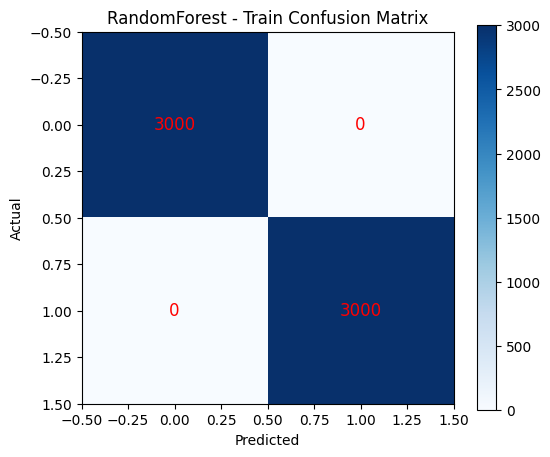

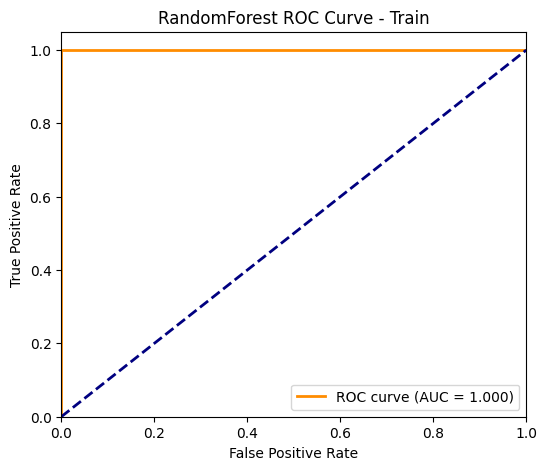

Validation Metrics:
Accuracy: 0.6795
F1-Score: 0.6674
ROC-AUC: 0.736577
Confusion Matrix:
[[716 284]
 [357 643]]


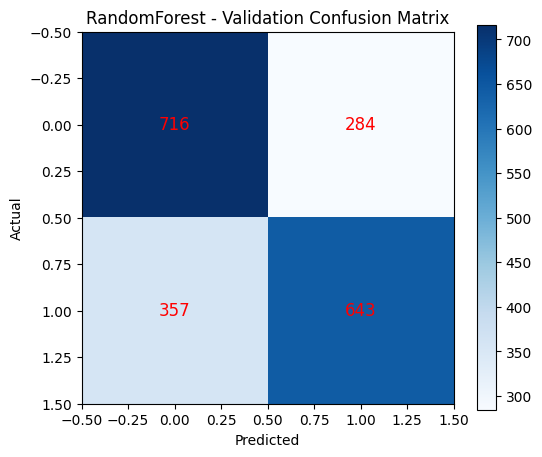

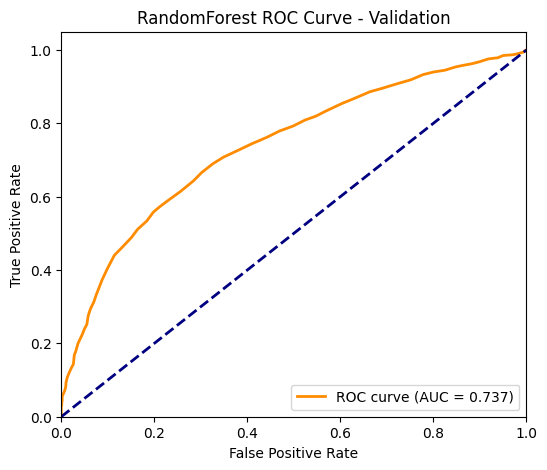

Test Metrics:
Accuracy: 0.6885
F1-Score: 0.6723
ROC-AUC: 0.7435350000000001
Confusion Matrix:
[[738 262]
 [361 639]]


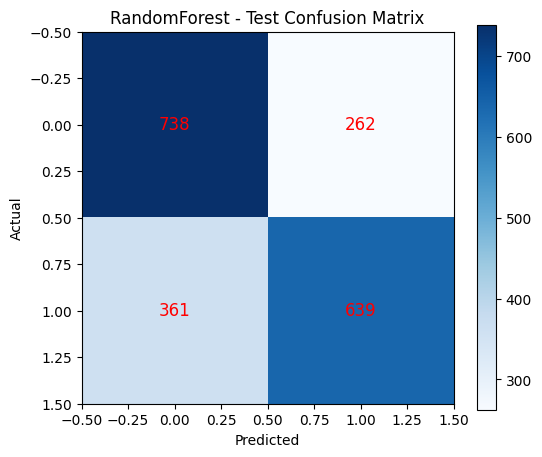

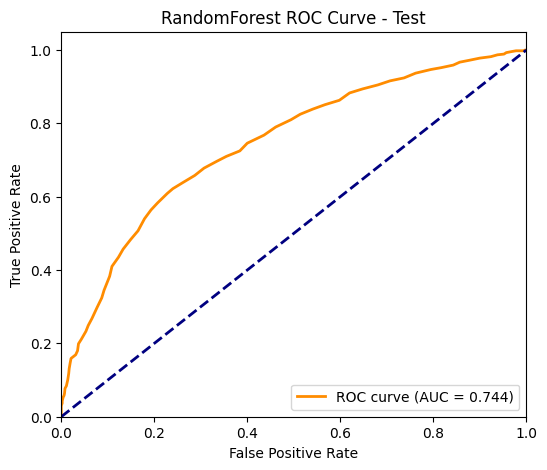


================ SVM ================

Train Metrics:
Accuracy: 0.7278
F1-Score: 0.6832
ROC-AUC: 0.8157745000000001
Confusion Matrix:
[[2606  394]
 [1239 1761]]


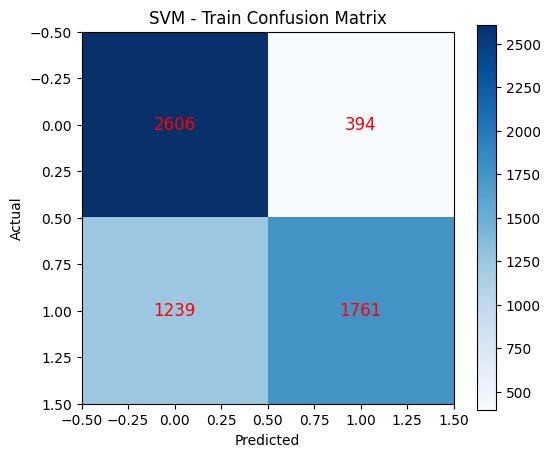

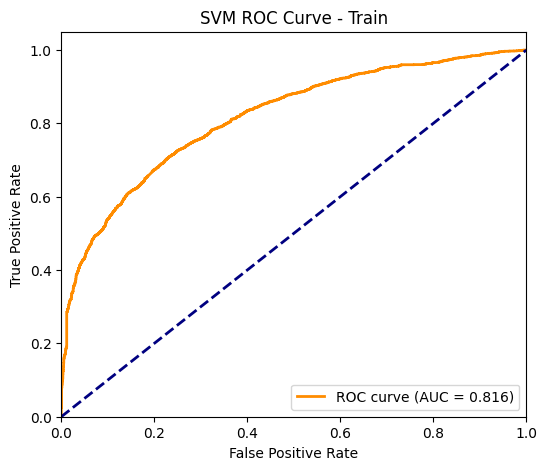

Validation Metrics:
Accuracy: 0.6855
F1-Score: 0.6341
ROC-AUC: 0.754816
Confusion Matrix:
[[826 174]
 [455 545]]


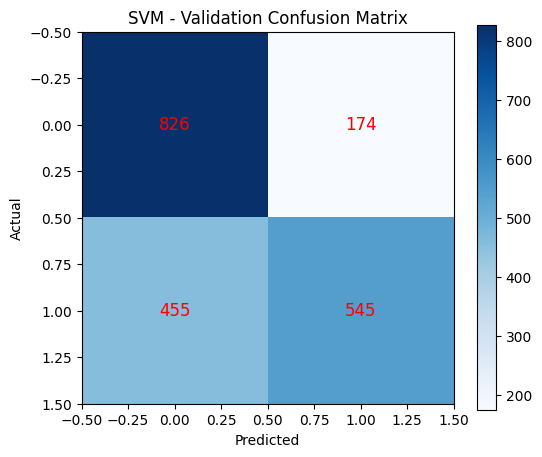

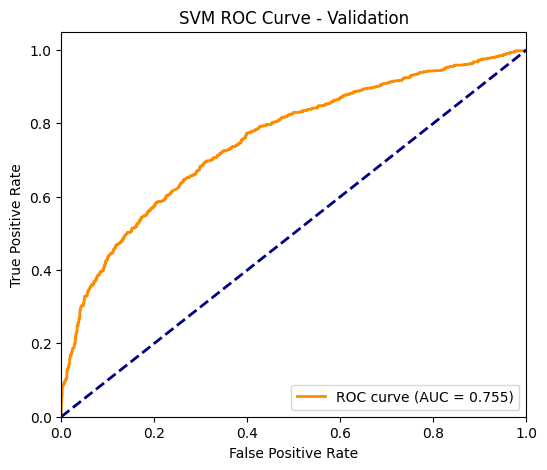

Test Metrics:
Accuracy: 0.6750
F1-Score: 0.6172
ROC-AUC: 0.758005
Confusion Matrix:
[[826 174]
 [476 524]]


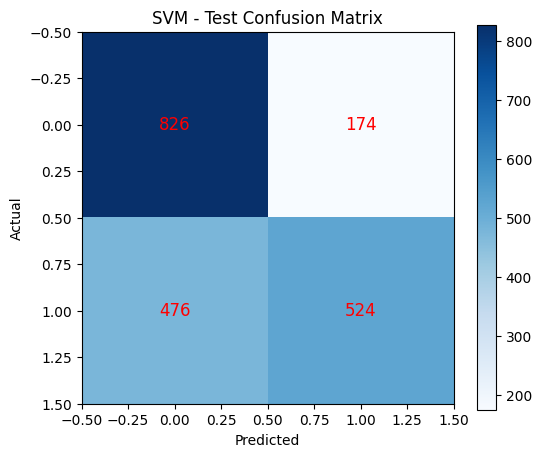

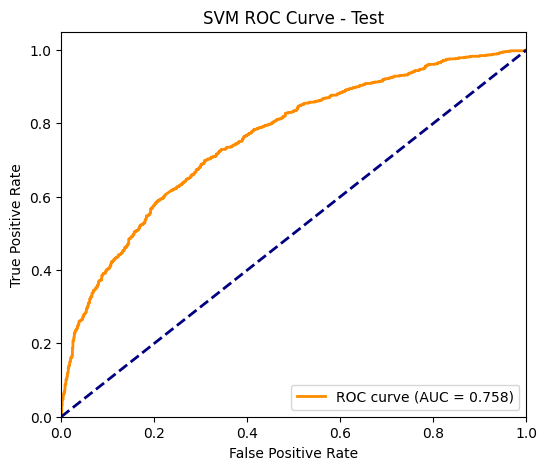


================ NaiveBayes ================

Train Metrics:
Accuracy: 0.5595
F1-Score: 0.3878
ROC-AUC: 0.6336859444444444
Confusion Matrix:
[[2520  480]
 [2163  837]]


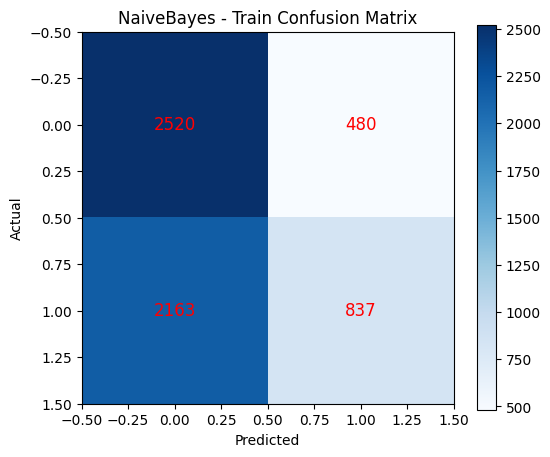

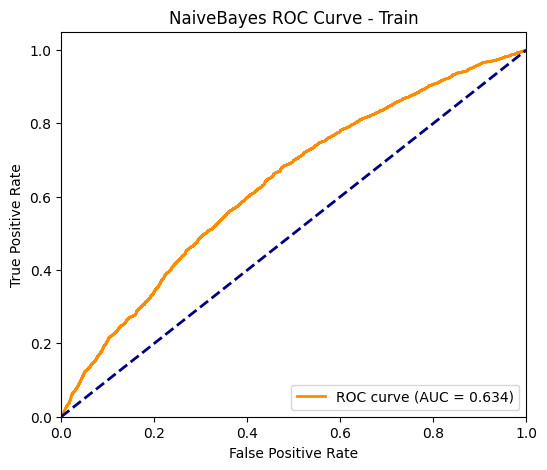

Validation Metrics:
Accuracy: 0.5680
F1-Score: 0.3924
ROC-AUC: 0.62452
Confusion Matrix:
[[857 143]
 [721 279]]


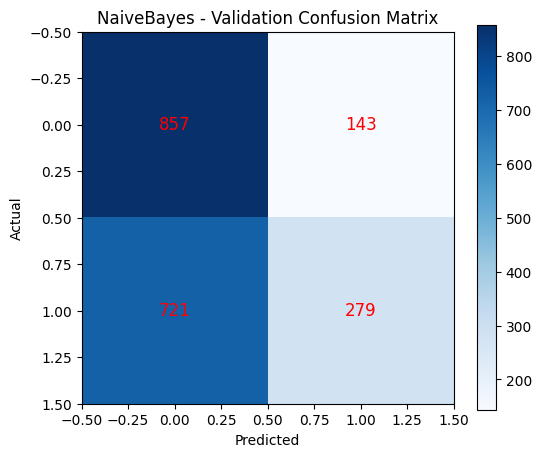

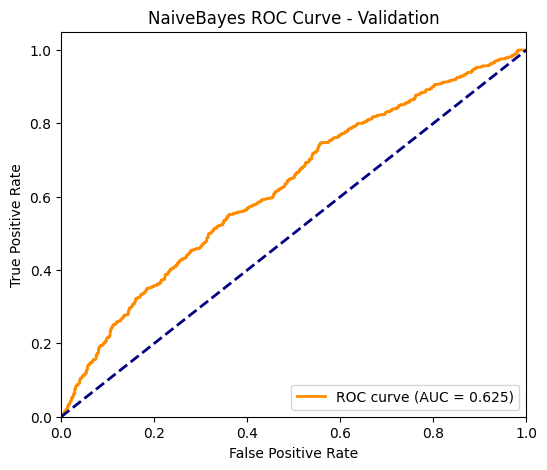

Test Metrics:
Accuracy: 0.5700
F1-Score: 0.3978
ROC-AUC: 0.643117
Confusion Matrix:
[[856 144]
 [716 284]]


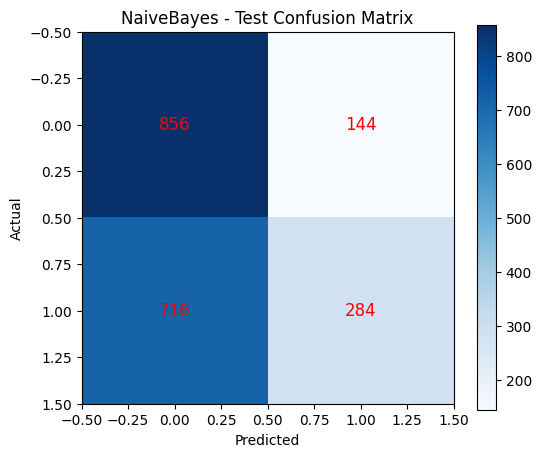

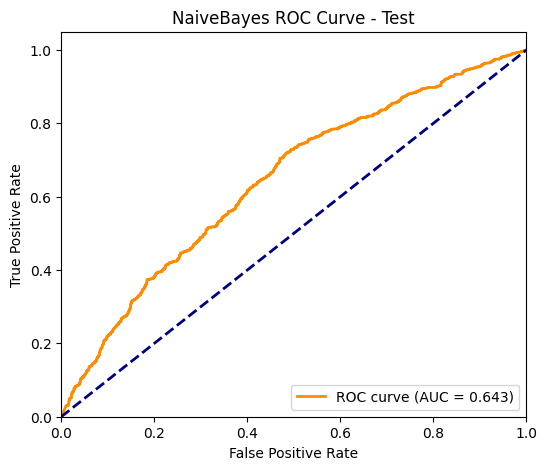


================ Stacking ================

Train Metrics:
Accuracy: 0.9480
F1-Score: 0.9477
ROC-AUC: 0.9917604444444443
Confusion Matrix:
[[2860  140]
 [ 172 2828]]


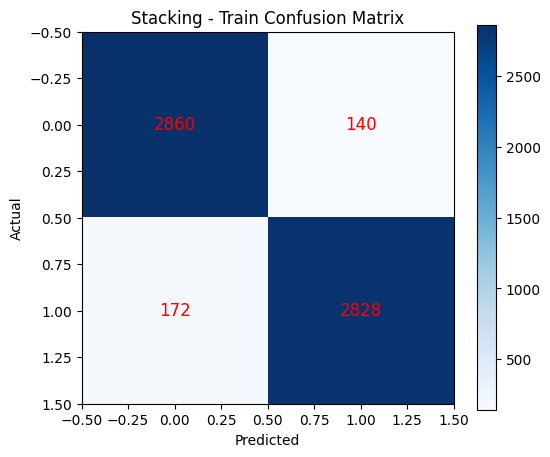

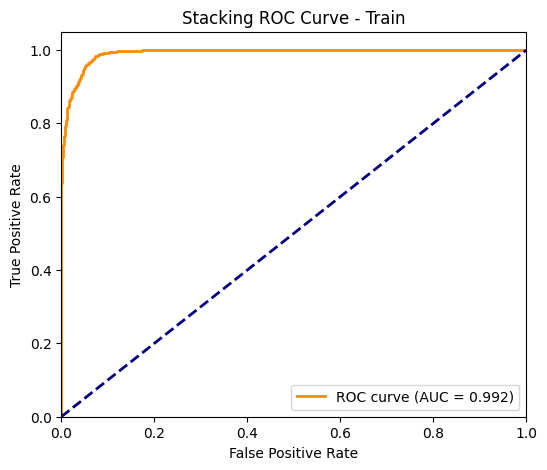

Validation Metrics:
Accuracy: 0.7020
F1-Score: 0.6899
ROC-AUC: 0.763636
Confusion Matrix:
[[741 259]
 [337 663]]


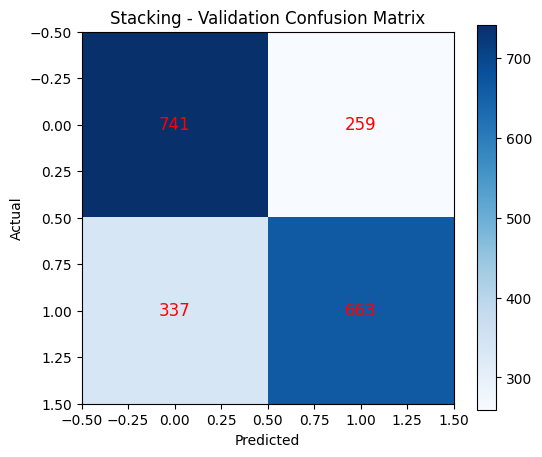

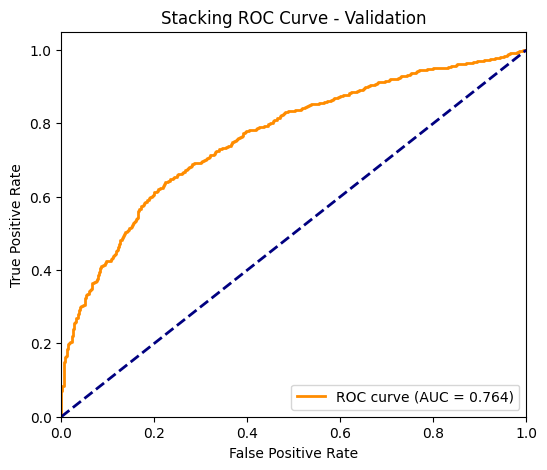

Test Metrics:
Accuracy: 0.7065
F1-Score: 0.6947
ROC-AUC: 0.7626109999999999
Confusion Matrix:
[[745 255]
 [332 668]]


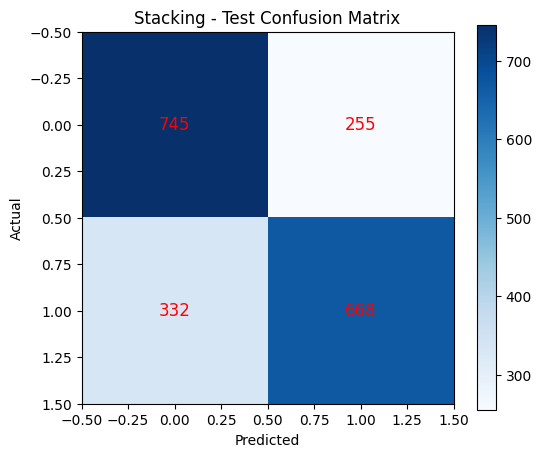

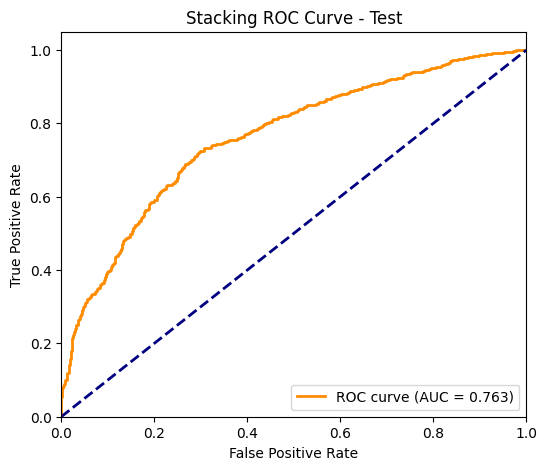

In [11]:
for model_name, data in metrics_dict.items():
    print(f"\n================ {model_name} ================\n")
    for dataset in ["Train", "Validation", "Test"]:
        print(f"{dataset} Metrics:")
        print(f"Accuracy: {data[dataset]['accuracy']:.4f}")
        print(f"F1-Score: {data[dataset]['f1']:.4f}")
        print(f"ROC-AUC: {data[dataset]['roc_auc'] if data[dataset]['roc_auc'] is not None else 'N/A'}")
        print("Confusion Matrix:")
        print(data[dataset]['conf_matrix'])

        cm = data[dataset]['conf_matrix']
        plt.figure(figsize=(6,5))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title(f"{model_name} - {dataset} Confusion Matrix")
        plt.colorbar()
        plt.xlabel("Predicted")
        plt.ylabel("Actual")

        # Add numeric values inside each cell
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, str(cm[i,j]), ha="center", va="center", color="red", fontsize=12)

        plt.show()


        # Plot ROC if possible
        if data[dataset]['roc_auc'] is not None:
            X_set = X_train if dataset=="Train" else (X_val if dataset=="Validation" else X_test)
            y_set = y_train if dataset=="Train" else (y_val if dataset=="Validation" else y_test)
            # Get the best estimator for the current model
            best_est = pipelines[model_name].fit(X_train, y_train)
            y_proba = best_est.predict_proba(X_set)[:,1]
            plot_roc(y_set, y_proba, dataset, model_name)

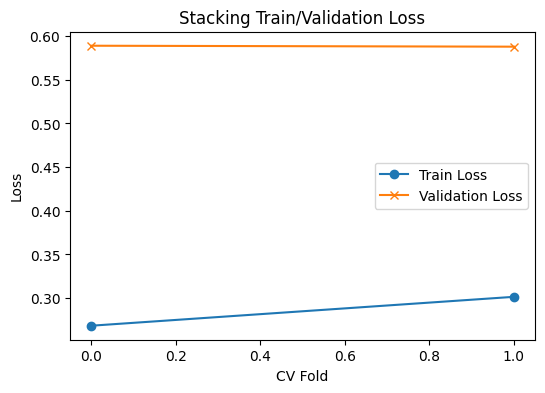

In [12]:
train_loss, val_loss = [], []

for train_idx, val_idx in cv.split(X_train, y_train):
    X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

    pipe = pipelines[best_name]
    pipe.fit(X_tr, y_tr)

    if hasattr(pipe, "predict_proba"):
        train_loss.append(log_loss(y_tr, pipe.predict_proba(X_tr)))
        val_loss.append(log_loss(y_va, pipe.predict_proba(X_va)))
    else:
        train_loss.append(1 - pipe.score(X_tr, y_tr))
        val_loss.append(1 - pipe.score(X_va, y_va))

plt.figure(figsize=(6,4))
plt.plot(range(len(train_loss)), train_loss, label='Train Loss', marker='o')
plt.plot(range(len(val_loss)), val_loss, label='Validation Loss', marker='x')
plt.xlabel('CV Fold')
plt.ylabel('Loss')
plt.title(f'{best_name} Train/Validation Loss')
plt.legend()
plt.show()


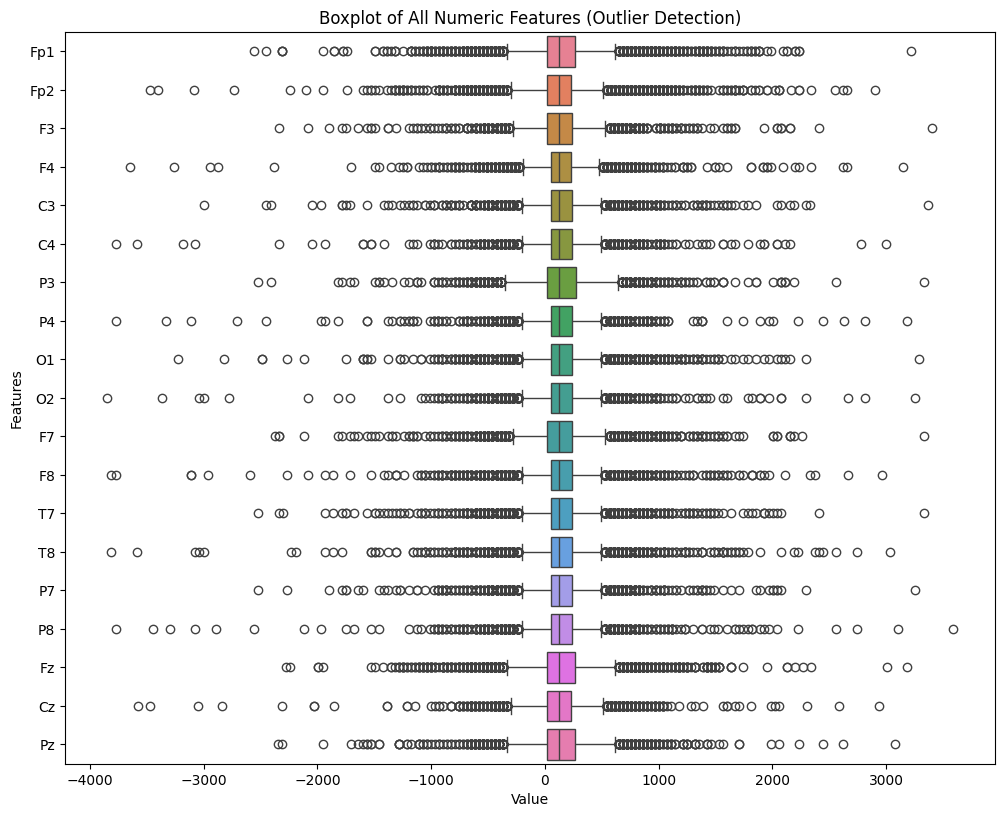

In [14]:
# Step: Combined Boxplot for all numeric features
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Remove target if numeric
if target in num_cols:
    num_cols.remove(target)

# Subset numeric columns
num_df = df[num_cols]

plt.figure(figsize=(12, max(6, len(num_cols)*0.5)))  # Adjust height based on number of columns
sns.boxplot(data=num_df, orient='h')
plt.title("Boxplot of All Numeric Features (Outlier Detection)")
plt.xlabel("Value")
plt.ylabel("Features")
plt.show()
